In [29]:
import geopandas as gdp
import folium
import matplotlib
!pip install mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 9.9 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
GP_prac = gdp.read_file('/content/drive/MyDrive/GeospatialData/GP_Practices_-_Scotland')

In [7]:
GP_prac.head(20)

,prac_code,uprn,address,postcode,local_auth,la_s_code,geometry
0,30030,9.051318e+09,"Garthdee Medical Group, Health Centre Garthdee...",AB10 7QQ,Aberdeen City,S12000033,POINT (391998 803177)
1,30059,9.051061e+09,"Holburn Medical Group, 7 Albyn Place, Aberdeen",AB10 1YE,Aberdeen City,S12000033,POINT (393187 805748)
2,30078,9.051066e+09,"Denburn Medical Practice, Denburn Health Centr...",AB25 1QB,Aberdeen City,S12000033,POINT (393610 806424)
3,30082,9.051132e+09,"Whinhill Medical Practice, 20 Whinhill Road, A...",AB11 7XH,Aberdeen City,S12000033,POINT (393514 804868)
4,30203,9.051151e+09,"Elmbank Group Practice, Foresterhill Health Ce...",AB25 2AY,Aberdeen City,S12000033,POINT (391377.5 806880.92)
5,30218,9.051043e+09,"Hamilton Medical Group, 4 Queens Road, Aberdeen",AB15 4ZT,Aberdeen City,S12000033,POINT (392259 805778)
6,30256,9.051007e+09,"Bucksburn Medical Practice, Bucksburn Clinic, ...",AB21 9DG,Aberdeen City,S12000033,POINT (389186 809608)
7,30261,9.051151e+09,"Westburn Medical Group, Foresterhill Health Ce...",AB25 2XE,Aberdeen City,S12000033,POINT (391377.5 806880.92)
8,30280,9.051154e+09,"New Dyce Medical Practice, Dyce Health Centre,...",AB21 7NQ,Aberdeen City,S12000033,POINT (389416 812859)
9,30294,9.051128e+09,"Torry Medical Practice, Torry Neighbourhood Ce...",AB11 8ER,Aberdeen City,S12000033,POINT (394736 804862)


<Axes: >

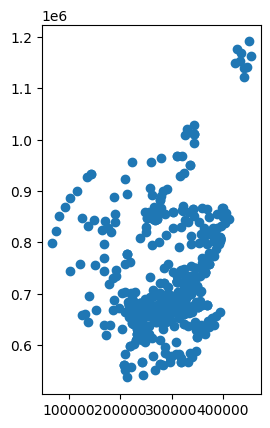

In [8]:
GP_prac.plot()

In [35]:
#Removed all GP practices not in Edinburgh. Also filtered out the GP practices in Linlithgow on 'Edinburgh Road'
edinburgh_GPs = GP_prac[GP_prac['address'].str.contains('Edinburgh', case=False, na=False) &
                           ~GP_prac['address'].str.contains('Edinburgh Road', case=False, na=False)]

# Display the first 10 rows of the filtered GeoDataFrame
edinburgh_GPs.head(10)

,prac_code,uprn,address,postcode,local_auth,la_s_code,geometry
107,70075,906042925.0,"Braids Medical Practice, 6 Camus Avenue, Edinb...",EH10 6QT,City of Edinburgh,S12000036,POINT (324487 668887)
108,70094,906132661.0,"The Green Practice, Stockbridge Health Centre,...",EH3 6EH,City of Edinburgh,S12000036,POINT (324719.57 674442.24)
109,70107,906200799.0,"Leven Medical Practice, Tollcross Health Centr...",EH3 9QQ,City of Edinburgh,S12000036,POINT (324794 672974)
110,70126,906172622.0,"Southfield Medical Practice, 132 Mountcastle D...",EH15 3LL,City of Edinburgh,S12000036,POINT (330355 672484)
111,70131,906056323.0,"Colinton Surgery, 296b Colinton Road, Edinburgh",EH13 0LB,City of Edinburgh,S12000036,POINT (321819 669123)
112,70164,906096872.0,"Ferniehill Surgery, 8 Ferniehill Road, Edinburgh",EH17 7AB,City of Edinburgh,S12000036,POINT (329222 668847)
113,70179,906496672.0,"Leith Surgery, 2 Duke Street, Edinburgh",EH6 8HQ,City of Edinburgh,S12000036,POINT (326988.48 675881.74)
114,70198,906180871.0,"Niddrie Medical Practice, Craigmillar Medical ...",EH16 4DT,City of Edinburgh,S12000036,POINT (329204 671620)
115,70215,906180871.0,"Craigmillar Medical Group, Craigmillar Medical...",EH16 4DT,City of Edinburgh,S12000036,POINT (329204 671620)
116,70234,906087824.0,"The Long House Surgery, The Long House, 73 Eas...",EH5 3EL,City of Edinburgh,S12000036,POINT (325106 676539)


In [36]:
edinburgh_GPs.explore()

In [37]:
#Using len() to see length of dataset
num_rows_len = len(edinburgh_GPs)
print(f"Number of rows: {num_rows_len}")

Number of rows: 66


In [39]:
output_shapefile_path = '/content/drive/MyDrive/GeospatialData/GP_Practices_Edinburgh.gpkg'

edinburgh_GPs.to_file(output_shapefile_path, driver='GPKG')
print(f"'edinburgh_hospitals' successfully exported to: {output_shapefile_path}")

'edinburgh_hospitals' successfully exported to: /content/drive/MyDrive/GeospatialData/GP_Practices_Edinburgh.gpkg
